In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from pathlib import Path


In [2]:
pd.set_option('display.max_rows', None)   # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full column content
pd.set_option('display.width', None)  # Don’t wrap columns


In [3]:
DATA_PATH = "03_unilife_baseline_database_3 [labels_var_categoricas] - banco .csv"

SMILE_COLS = [
    "smile_food_1", "smile_food_2", "smile_food_3",
    "smile_subs_1", "smile_subs_2", "smile_subs_3", "smile_subs_4",
    "smile_PA_1", "smile_PA_2", "smile_PA_3",
    "smile_stress_1", "smile_stress_2",
    "smile_sleep_1", "smile_sleep_2", "smile_sleep_3",
    "smile_social_1", "smile_social_2", "smile_social_3", "smile_social_4", "smile_social_5",
    "smile_env_1", "smile_env_2", "smile_env_3", "smile_env_4",
]

raw = pd.read_csv(DATA_PATH)

df = raw[SMILE_COLS + ["Severity_GAD7"]].copy()

# Binary GAD-7 severity target: Sem_sintoma/Leve (0,1) -> 0, Moderado/Severo (2,3) -> 1
df["gad7_sev"] = df["Severity_GAD7"].map({0: 0, 1: 0, 2: 1, 3: 1})
df = df.drop(columns=["Severity_GAD7"])

df = df.dropna(subset=["gad7_sev"])
df["gad7_sev"] = df["gad7_sev"].astype(int)

severe_gad7_indexes = df[df["gad7_sev"] == 1].index.tolist()

print(f"{df.shape[0]} rows, {df.shape[1]} columns")
print(df["gad7_sev"].value_counts())
df.describe()


5601 rows, 25 columns
gad7_sev
1    2803
0    2798
Name: count, dtype: int64


,smile_food_1,smile_food_2,smile_food_3,smile_subs_1,smile_subs_2,smile_subs_3,smile_subs_4,smile_PA_1,smile_PA_2,smile_PA_3,smile_stress_1,smile_stress_2,smile_sleep_1,smile_sleep_2,smile_sleep_3,smile_social_1,smile_social_2,smile_social_3,smile_social_4,smile_social_5,smile_env_1,smile_env_2,smile_env_3,smile_env_4,gad7_sev
count,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000
mean,1.808963,2.686842,3.081771,3.428138,3.782717,3.814854,3.976611,2.547759,1.679522,2.979468,1.709338,2.292805,2.607392,2.247634,2.191930,3.391894,2.839314,2.950187,2.897340,3.245135,1.878415,1.440100,2.396715,2.766113,0.500446
std,0.921527,0.681741,0.761173,0.756322,0.597998,0.540998,0.184166,1.059100,0.958584,1.080562,0.960543,1.183503,0.836196,0.859561,0.896688,0.719721,0.896360,1.030525,0.959536,0.780159,0.908315,0.672436,0.817061,1.022218,0.500044
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,1.000000,1.000000,2.000000,2.000000,0.000000
50%,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,2.000000,1.000000,3.000000,1.000000,2.000000,3.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,2.000000,3.000000,1.000000
75%,2.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,2.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,3.000000,4.000000,1.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000


In [4]:
X = df.drop(columns=["gad7_sev"])
y = df["gad7_sev"]

valid_mask = y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

if y.isna().any():
    raise ValueError("y contains NaN values after filtering.")

data_idx = X.index.to_numpy()

print(f"{X.shape[0]} rows, {X.shape[1]} columns")
X.describe()


5601 rows, 24 columns


,smile_food_1,smile_food_2,smile_food_3,smile_subs_1,smile_subs_2,smile_subs_3,smile_subs_4,smile_PA_1,smile_PA_2,smile_PA_3,smile_stress_1,smile_stress_2,smile_sleep_1,smile_sleep_2,smile_sleep_3,smile_social_1,smile_social_2,smile_social_3,smile_social_4,smile_social_5,smile_env_1,smile_env_2,smile_env_3,smile_env_4
count,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000,5601.000000
mean,1.808963,2.686842,3.081771,3.428138,3.782717,3.814854,3.976611,2.547759,1.679522,2.979468,1.709338,2.292805,2.607392,2.247634,2.191930,3.391894,2.839314,2.950187,2.897340,3.245135,1.878415,1.440100,2.396715,2.766113
std,0.921527,0.681741,0.761173,0.756322,0.597998,0.540998,0.184166,1.059100,0.958584,1.080562,0.960543,1.183503,0.836196,0.859561,0.896688,0.719721,0.896360,1.030525,0.959536,0.780159,0.908315,0.672436,0.817061,1.022218
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,1.000000,1.000000,2.000000,2.000000
50%,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,2.000000,1.000000,3.000000,1.000000,2.000000,3.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,2.000000,3.000000
75%,2.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,2.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,3.000000,4.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [5]:
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

shuffle_split = ShuffleSplit(n_splits=5, test_size=0.2, random_state=50)
splits = []

numerical_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=1)),
    ("scaler", StandardScaler())
])

for train_pos, test_pos in shuffle_split.split(data_idx):
    train_idx = data_idx[train_pos]
    test_idx = data_idx[test_pos]

    X_train, X_test_og = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    X_train_transformed = numerical_pipeline.fit_transform(X_train)
    X_test_transformed = numerical_pipeline.transform(X_test_og)

    X_train_imputed = pd.DataFrame(X_train_transformed, index=X_train.index, columns=X.columns)
    X_test_imputed = pd.DataFrame(X_test_transformed, index=X_test_og.index, columns=X.columns)

    splits.append({
        "X_train": X_train_imputed,
        "X_test": X_test_imputed,
        "X_test_og": X_test_og,  # original 1-4 Likert scale, for SHAP display coloring
        "y_train": y_train,
        "y_test": y_test
    })

print(f"Treino: {splits[0]['X_train'].shape}, Teste: {splits[0]['X_test'].shape}")


Treino: (4480, 24), Teste: (1121, 24)


In [6]:
splits[0]['X_train'].describe()

,smile_food_1,smile_food_2,smile_food_3,smile_subs_1,smile_subs_2,smile_subs_3,smile_subs_4,smile_PA_1,smile_PA_2,smile_PA_3,smile_stress_1,smile_stress_2,smile_sleep_1,smile_sleep_2,smile_sleep_3,smile_social_1,smile_social_2,smile_social_3,smile_social_4,smile_social_5,smile_env_1,smile_env_2,smile_env_3,smile_env_4
count,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03,4.480000e+03
mean,4.440892e-17,-3.076904e-16,1.712916e-16,2.612989e-16,1.070572e-17,1.284687e-16,3.639945e-16,8.643879e-17,7.930164e-19,2.537653e-17,1.704985e-17,1.697055e-16,2.537653e-17,-6.661338e-17,7.573307e-17,-2.640745e-16,-1.689125e-16,-1.839798e-16,-2.363189e-16,7.137148e-18,8.723181e-17,-1.522592e-16,-1.823938e-17,-1.318390e-16
std,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00,1.000112e+00
min,-8.823500e-01,-2.497581e+00,-2.738525e+00,-3.243452e+00,-4.694399e+00,-5.366459e+00,-1.703501e+01,-1.465194e+00,-7.084397e-01,-1.827015e+00,-7.412145e-01,-1.092310e+00,-1.923266e+00,-1.456714e+00,-1.340792e+00,-3.369401e+00,-2.083264e+00,-1.899569e+00,-1.974491e+00,-2.894732e+00,-9.749980e-01,-6.584402e-01,-1.718372e+00,-1.727767e+00
25%,-8.823500e-01,-1.019098e+00,-1.040840e-01,-5.809389e-01,3.627285e-01,3.446194e-01,1.212683e-01,-5.137417e-01,-7.084397e-01,-9.003733e-01,-7.412145e-01,-1.092310e+00,-7.250696e-01,-2.892581e-01,-2.171953e-01,-5.618280e-01,-9.601567e-01,-9.272119e-01,-9.327151e-01,-3.167777e-01,-9.749980e-01,-6.584402e-01,-4.970002e-01,-7.494562e-01
50%,2.012377e-01,4.593860e-01,-1.040840e-01,7.503175e-01,3.627285e-01,3.446194e-01,1.212683e-01,-5.137417e-01,-7.084397e-01,2.626864e-02,-7.412145e-01,-2.539429e-01,4.731273e-01,-2.892581e-01,-2.171953e-01,8.419586e-01,1.629509e-01,4.514515e-02,1.090609e-01,-3.167777e-01,1.327857e-01,-6.584402e-01,-4.970002e-01,2.288549e-01
75%,2.012377e-01,4.593860e-01,1.213137e+00,7.503175e-01,3.627285e-01,3.446194e-01,1.212683e-01,4.377105e-01,3.359203e-01,9.529106e-01,2.977845e-01,1.422791e+00,4.731273e-01,8.781981e-01,9.064016e-01,8.419586e-01,1.286058e+00,1.017502e+00,1.150837e+00,9.721997e-01,1.240569e+00,8.113217e-01,7.243717e-01,1.207166e+00
max,2.368413e+00,1.937870e+00,1.213137e+00,7.503175e-01,3.627285e-01,3.446194e-01,1.212683e-01,1.389163e+00,2.424640e+00,9.529106e-01,2.375783e+00,1.422791e+00,1.671324e+00,2.045654e+00,2.029999e+00,8.419586e-01,1.286058e+00,1.017502e+00,1.150837e+00,9.721997e-01,2.348353e+00,3.750846e+00,1.945744e+00,1.207166e+00


XGBoost

In [7]:
import shap
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, sampling_strategy="minority", k_neighbors=1)

prec_list, recall_list, f1_list = [], [], []

for i, split in enumerate(splits):
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)

    xgb_clf = XGBClassifier(tree_method="hist", device="cpu", random_state=42)
    xgb_clf.fit(X_train_rs, y_train_rs)
    predictions = xgb_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average="macro")
    f1 = f1_score(y_test, predictions, average="macro")
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec); recall_list.append(recall); f1_list.append(f1)

print("Average Precision: {:.3f}".format(np.mean(prec_list)))
print("Average Recall: {:.3f}".format(np.mean(recall_list)))
print("Average F1-Score: {:.3f}".format(np.mean(f1_list)))


/home/joao/lasos2026/lasos2026/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Split 1 -- Precision: 0.625, Recall: 0.635, F1-Score: 0.635


Split 2 -- Precision: 0.640, Recall: 0.649, F1-Score: 0.649


Split 3 -- Precision: 0.649, Recall: 0.627, F1-Score: 0.626


Split 4 -- Precision: 0.670, Recall: 0.657, F1-Score: 0.657


Split 5 -- Precision: 0.623, Recall: 0.639, F1-Score: 0.639
Average Precision: 0.641
Average Recall: 0.642
Average F1-Score: 0.641


Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42, sampling_strategy="minority", k_neighbors=1)

prec_list, recall_list, f1_list = [], [], []

for i, split in enumerate(splits):
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)

    rf_clf = RandomForestClassifier(random_state=42)
    rf_clf.fit(X_train_rs, y_train_rs)
    predictions = rf_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average="macro")
    f1 = f1_score(y_test, predictions, average="macro")
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec); recall_list.append(recall); f1_list.append(f1)

print("Average Precision: {:.3f}".format(np.mean(prec_list)))
print("Average Recall: {:.3f}".format(np.mean(recall_list)))
print("Average F1-Score: {:.3f}".format(np.mean(f1_list)))


Split 1 -- Precision: 0.661, Recall: 0.665, F1-Score: 0.665


Split 2 -- Precision: 0.648, Recall: 0.657, F1-Score: 0.657


Split 3 -- Precision: 0.682, Recall: 0.656, F1-Score: 0.655


Split 4 -- Precision: 0.685, Recall: 0.666, F1-Score: 0.665


Split 5 -- Precision: 0.651, Recall: 0.665, F1-Score: 0.665
Average Precision: 0.665
Average Recall: 0.662
Average F1-Score: 0.661


Light GBM

In [9]:
import lightgbm as lgb

smote = SMOTE(random_state=42, k_neighbors=1)

prec_list, recall_list, f1_list = [], [], []

for i, split in enumerate(splits):
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)

    lgb_clf = lgb.LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)
    lgb_clf.fit(X_train_rs, y_train_rs)
    predictions = lgb_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average="macro")
    f1 = f1_score(y_test, predictions, average="macro")
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec); recall_list.append(recall); f1_list.append(f1)

print("Average Precision: {:.3f}".format(np.mean(prec_list)))
print("Average Recall: {:.3f}".format(np.mean(recall_list)))
print("Average F1-Score: {:.3f}".format(np.mean(f1_list)))


Split 1 -- Precision: 0.642, Recall: 0.650, F1-Score: 0.650


Split 2 -- Precision: 0.647, Recall: 0.655, F1-Score: 0.655


Split 3 -- Precision: 0.665, Recall: 0.646, F1-Score: 0.646


Split 4 -- Precision: 0.676, Recall: 0.654, F1-Score: 0.653


Split 5 -- Precision: 0.651, Recall: 0.666, F1-Score: 0.665
Average Precision: 0.656
Average Recall: 0.654
Average F1-Score: 0.654


SVM

In [10]:
from sklearn.svm import SVC

smote = SMOTE(random_state=42, sampling_strategy="minority", k_neighbors=1)

prec_list, recall_list, f1_list = [], [], []

for i, split in enumerate(splits):
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)

    svm_clf = SVC(kernel="rbf", random_state=42)
    svm_clf.fit(X_train_rs, y_train_rs)
    predictions = svm_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average="macro")
    f1 = f1_score(y_test, predictions, average="macro")
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec); recall_list.append(recall); f1_list.append(f1)

print("Average Precision: {:.3f}".format(np.mean(prec_list)))
print("Average Recall: {:.3f}".format(np.mean(recall_list)))
print("Average F1-Score: {:.3f}".format(np.mean(f1_list)))


Split 1 -- Precision: 0.661, Recall: 0.675, F1-Score: 0.674


Split 2 -- Precision: 0.655, Recall: 0.666, F1-Score: 0.665


Split 3 -- Precision: 0.680, Recall: 0.657, F1-Score: 0.657


Split 4 -- Precision: 0.685, Recall: 0.665, F1-Score: 0.664


Split 5 -- Precision: 0.650, Recall: 0.666, F1-Score: 0.665
Average Precision: 0.666
Average Recall: 0.666
Average F1-Score: 0.665


Logistic Regression — final model used for SHAP explainability

In [11]:
# ── LogisticRegression hyperparameter optimization with hyperopt ───────────────────────
from hyperopt.fmin import fmin
from hyperopt.tpe import suggest as tpe_suggest
from hyperopt.hp import loguniform, choice, quniform
from hyperopt.base import Trials, STATUS_OK
from sklearn.linear_model import LogisticRegression

smote_opt = SMOTE(random_state=42, sampling_strategy="minority", k_neighbors=1)

lr_space = {
    "C": loguniform("C", np.log(1e-3), np.log(10)),
    "class_weight": choice("class_weight", [None, "balanced"]),
    "max_iter": quniform("max_iter", 500, 2000, 100),
}

class_weight_choices = [None, "balanced"]

def lr_objective(params):
    f1_scores = []
    for split in splits:
        X_train_rs, y_train_rs = smote_opt.fit_resample(split["X_train"], split["y_train"])
        clf = LogisticRegression(
            C=params["C"], class_weight=params["class_weight"],
            max_iter=int(params["max_iter"]), solver="liblinear", random_state=42,
        )
        clf.fit(X_train_rs, y_train_rs)
        preds = clf.predict(split["X_test"])
        f1_scores.append(f1_score(split["y_test"], preds, average="macro"))
    return {"loss": -np.mean(f1_scores), "status": STATUS_OK}

lr_trials = Trials()
lr_best_raw = fmin(
    fn=lr_objective,
    space=lr_space,
    algo=tpe_suggest,
    max_evals=30,
    trials=lr_trials,
    rstate=np.random.default_rng(42),
)

lr_best = {
    "C": lr_best_raw["C"],
    "class_weight": class_weight_choices[int(lr_best_raw["class_weight"])],
    "max_iter": int(lr_best_raw["max_iter"]),
    "solver": "liblinear",
}

print("Best LogisticRegression params:", lr_best)
print(f"Best CV macro-F1: {-min(lr_trials.losses()):.4f}")


  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

/home/joao/lasos2026/lasos2026/.venv/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


  3%|▎         | 1/30 [00:00<00:08,  3.31trial/s, best loss: -0.6633145930720649]

  7%|▋         | 2/30 [00:00<00:08,  3.42trial/s, best loss: -0.6633145930720649]

 10%|█         | 3/30 [00:00<00:07,  3.48trial/s, best loss: -0.663671310286564] 

...

 93%|█████████▎| 28/30 [00:07<00:00,  3.97trial/s, best loss: -0.6699197148077237]

 97%|█████████▋| 29/30 [00:07<00:00,  4.08trial/s, best loss: -0.6699197148077237]

100%|██████████| 30/30 [00:08<00:00,  4.15trial/s, best loss: -0.6699197148077237]

100%|██████████| 30/30 [00:08<00:00,  3.73trial/s, best loss: -0.6699197148077237]


Best LogisticRegression params: {'C': np.float64(0.006845749011390111), 'class_weight': 'balanced', 'max_iter': 1400, 'solver': 'liblinear'}
Best CV macro-F1: 0.6699


In [12]:
smote = SMOTE(random_state=42, sampling_strategy="minority", k_neighbors=1)

prec_list, recall_list, f1_list = [], [], []
all_shap_values = []
all_X_tests = []
all_X_test_ogs = []
all_coefs = []

for i, split in enumerate(splits):
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)

    log_reg = LogisticRegression(random_state=42, **lr_best)
    log_reg.fit(X_train_rs, y_train_rs)
    predictions = log_reg.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average="macro")
    f1 = f1_score(y_test, predictions, average="macro")
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec); recall_list.append(recall); f1_list.append(f1)
    all_coefs.append(pd.Series(log_reg.coef_[0], index=X_train.columns))

    explainer = shap.LinearExplainer(log_reg, X_train_rs)
    shap_values = explainer.shap_values(X_test)
    shap_df_split = pd.DataFrame(shap_values, index=X_test.index, columns=X_train.columns)

    all_shap_values.append(shap_df_split)
    all_X_tests.append(X_test.copy())
    all_X_test_ogs.append(split["X_test_og"].copy())

print("Average Precision: {:.3f}".format(np.mean(prec_list)))
print("Average Recall: {:.3f}".format(np.mean(recall_list)))
print("Average F1-Score: {:.3f}".format(np.mean(f1_list)))


Split 1 -- Precision: 0.658, Recall: 0.664, F1-Score: 0.664


Split 2 -- Precision: 0.653, Recall: 0.665, F1-Score: 0.665
Split 3 -- Precision: 0.683, Recall: 0.662, F1-Score: 0.661
Split 4 -- Precision: 0.693, Recall: 0.678, F1-Score: 0.678


Split 5 -- Precision: 0.668, Recall: 0.683, F1-Score: 0.682
Average Precision: 0.671
Average Recall: 0.670
Average F1-Score: 0.670


In [13]:
# Mean LogisticRegression weight per U-SMILE item, averaged over the 5 splits.
# Coefficients are on the standardized (z-scored) feature scale, so they are
# directly comparable to each other: sign = direction, magnitude = strength.
coefs_df = pd.concat(all_coefs, axis=1)
mean_coefs = coefs_df.mean(axis=1).sort_values(key=abs, ascending=False)
std_coefs = coefs_df.std(axis=1)

weights_summary = pd.DataFrame({
    "mean_weight": mean_coefs,
    "std_across_splits": std_coefs.loc[mean_coefs.index],
})
print("Logistic Regression weights (standardized scale, sorted by |mean|):")
weights_summary


Logistic Regression weights (standardized scale, sorted by |mean|):


,mean_weight,std_across_splits
smile_sleep_2,-0.270094,0.005627
smile_social_2,-0.258557,0.017344
smile_stress_1,0.201960,0.014590
smile_food_2,-0.192320,0.015182
smile_sleep_1,-0.181078,0.017246
smile_env_2,-0.178905,0.017784
smile_sleep_3,-0.175069,0.012954
smile_subs_1,-0.129275,0.012673
smile_PA_3,-0.126247,0.027498
smile_env_4,0.120761,0.011974


SHAP — U-SMILE domains

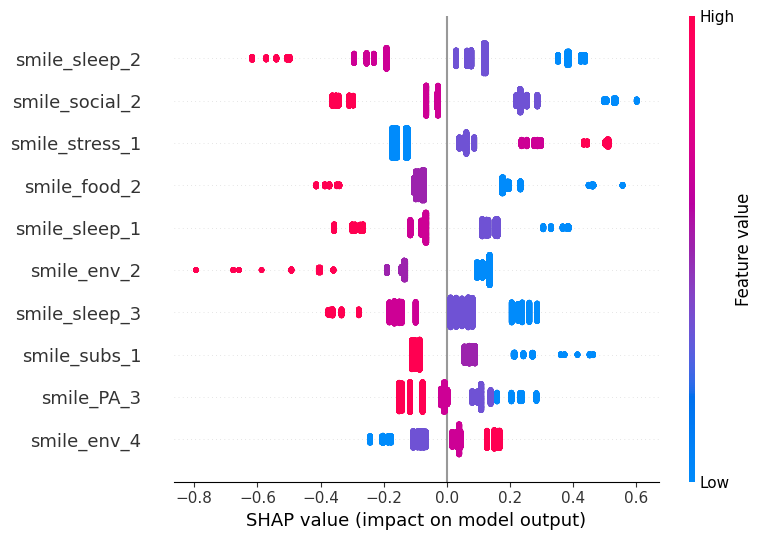

In [14]:
import shap
from pathlib import Path

_FIG_DIR = Path.cwd() / "brasil" if (Path.cwd() / "brasil").is_dir() else Path.cwd()

shap_df_all = pd.concat(all_shap_values, axis=0, ignore_index=False)
X_test_all = pd.concat(all_X_tests, axis=0, ignore_index=False)
X_test_og_all = pd.concat(all_X_test_ogs, axis=0, ignore_index=False)

expl = shap.Explanation(
    values=shap_df_all.values,
    data=X_test_og_all[shap_df_all.columns].values,
    feature_names=list(shap_df_all.columns),
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
plt.tight_layout()
plt.savefig(_FIG_DIR / "br_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


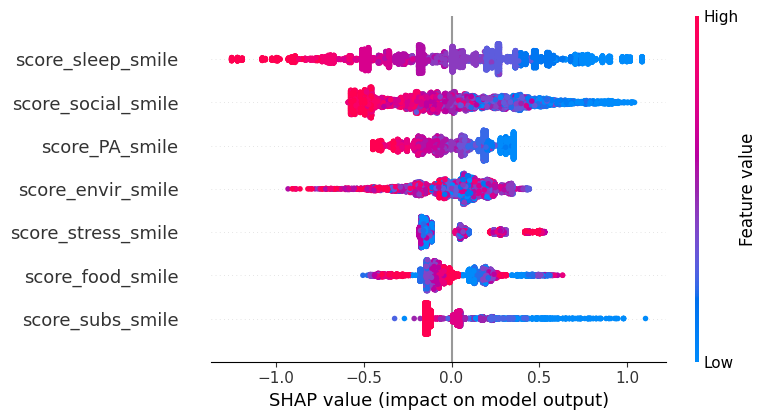

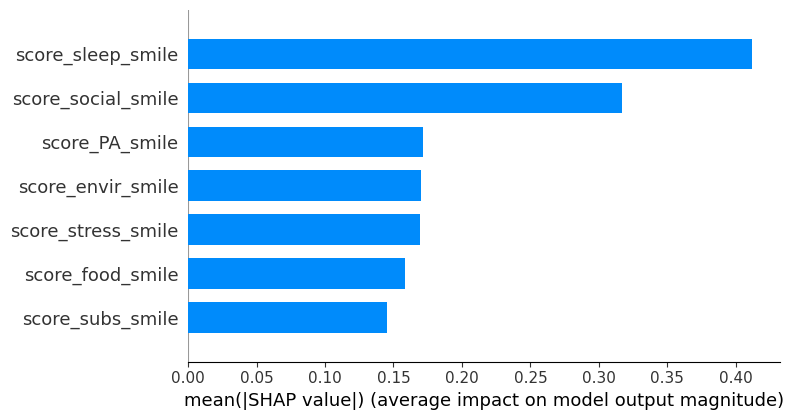

In [15]:
smile_variable_groups = {
    "score_food_smile": ["smile_food_1", "smile_food_2", "smile_food_3"],
    "score_subs_smile": ["smile_subs_1", "smile_subs_2", "smile_subs_3", "smile_subs_4"],
    "score_PA_smile": ["smile_PA_1", "smile_PA_2", "smile_PA_3"],
    "score_stress_smile": ["smile_stress_1", "smile_stress_2"],
    "score_sleep_smile": ["smile_sleep_1", "smile_sleep_2", "smile_sleep_3"],
    "score_social_smile": ["smile_social_1", "smile_social_2", "smile_social_3", "smile_social_4", "smile_social_5"],
    "score_envir_smile": ["smile_env_1", "smile_env_2", "smile_env_3", "smile_env_4"],
}

feature_to_group_map = {}
for group_name, features in smile_variable_groups.items():
    for feature in features:
        feature_to_group_map[feature] = group_name

def aggregate_features(feature_name):
    return feature_to_group_map.get(feature_name, feature_name)

shap_df_agg = shap_df_all.T.groupby(shap_df_all.columns.map(aggregate_features)).sum().T

X_test_agg = pd.DataFrame(
    {col_group: X_test_og_all[smile_variable_groups[col_group]].mean(axis=1).values
      for col_group in shap_df_agg.columns},
    index=X_test_og_all.index,
)

common_columns = list(shap_df_agg.columns)

expl = shap.Explanation(
    values=shap_df_agg.values,
    data=X_test_agg[common_columns].values,
    feature_names=common_columns,
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(expl, max_display=7, group_remaining_features=False, show=False)
plt.tight_layout()
plt.savefig(_FIG_DIR / "br_beeswarm_g.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_df_agg[common_columns].values,
    X_test_agg[common_columns],
    plot_type="bar",
    feature_names=common_columns,
    show=False
)
plt.tight_layout()
plt.savefig(_FIG_DIR / "br_bar.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


SHAP - casos graves

Total de amostras: 5605
Amostras GAD7 graves (moderado+severo): 2800


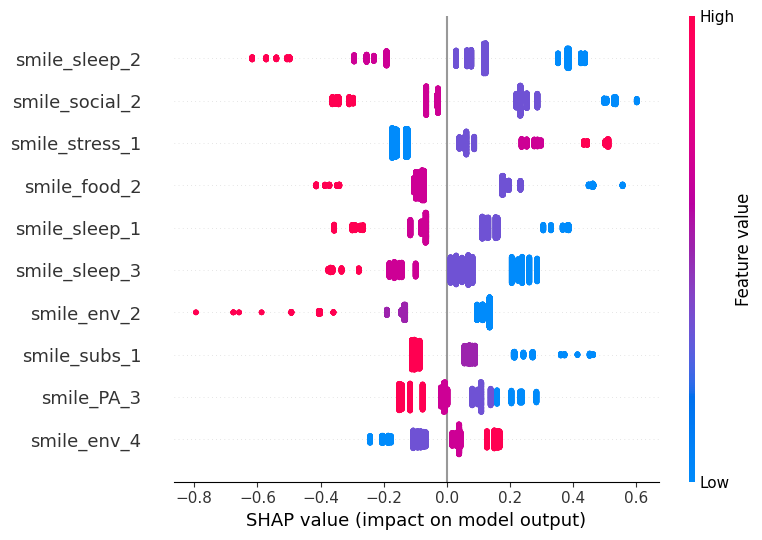

In [16]:
severe_mask = shap_df_all.index.isin(severe_gad7_indexes)
shap_df_severe = shap_df_all.loc[severe_mask]
X_test_og_severe = X_test_og_all.loc[severe_mask]

print(f"Total de amostras: {len(shap_df_all)}")
print(f"Amostras GAD7 graves (moderado+severo): {len(shap_df_severe)}")

expl = shap.Explanation(
    values=shap_df_severe.values,
    data=X_test_og_severe[shap_df_severe.columns].values,
    feature_names=list(shap_df_severe.columns),
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
plt.tight_layout()
plt.savefig(_FIG_DIR / "br_severe_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


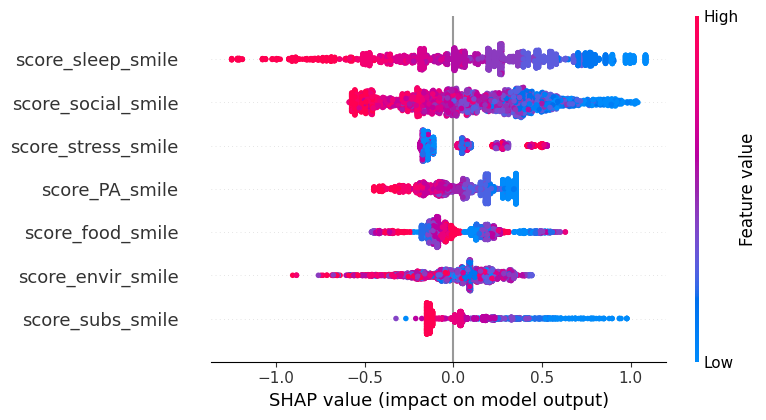

In [17]:
shap_df_agg_severe = shap_df_severe.T.groupby(shap_df_severe.columns.map(aggregate_features)).sum().T

X_test_agg_severe = pd.DataFrame(
    {col_group: X_test_og_severe[smile_variable_groups[col_group]].mean(axis=1).values
     for col_group in shap_df_agg_severe.columns},
    index=X_test_og_severe.index,
)

common_columns = list(shap_df_agg_severe.columns)

expl = shap.Explanation(
    values=shap_df_agg_severe.values,
    data=X_test_agg_severe[common_columns].values,
    feature_names=common_columns,
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(expl, max_display=7, group_remaining_features=False, show=False)
plt.tight_layout()
plt.savefig(_FIG_DIR / "br_severe_beeswarm_g.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
